__Goal__

We will implement a linear regression model using torch.linalg

__Linear Regression Problem__

Given a sequence of input-output pairs
$$
\{(x_i, y_i): i = 1, 2, \ldots, n\},
$$
the goal is to find parameters $(w, b)$ such that the linear function
$$
y = f(x) = wx + b
$$
fits the data well. Formally, we solve:
$$
(w, b) = \arg\min_{w, b} \sum_i \left|y_i - f(x_i)\right|^2.
$$

In [1]:
# package imports
import torch
import torch.nn as nn
import torch.optim as optim

import matplotlib.pyplot as plt
import numpy as np
import time

In [2]:
# parameters for synthetic data generation
bias_param = 5.0
weight_param = 2.0
noise_std = 1.0

In [3]:
# Create synthetic training data of size 50 and test data of size 20 (reproducible)
batch_size = 50
torch.manual_seed(42)

x_train = torch.arange(batch_size, dtype=torch.float32).reshape(-1, 1)
y_train = bias_param + weight_param * x_train + torch.randn(batch_size, 1) * noise_std

x_test = torch.arange(batch_size, batch_size + 20, dtype=torch.float32).reshape(-1, 1)
y_test = bias_param + weight_param * x_test + torch.randn(20, 1) * noise_std

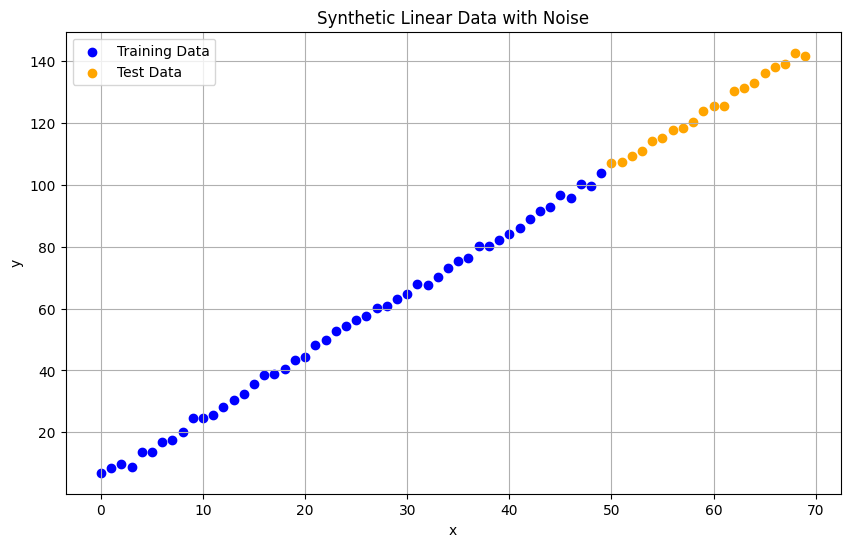

In [4]:
# plot the training and test data
plt.figure(figsize=(10, 6))
plt.scatter(x_train.numpy(), y_train.numpy(), color='blue', label='Training Data')
plt.scatter(x_test.numpy(), y_test.numpy(), color='orange', label='Test Data')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Synthetic Linear Data with Noise')
plt.legend()
plt.grid()
plt.show()

__Linear Algebra approach__

Set
$$A = \begin{pmatrix}
1 & x_1 \\
1 & x_2 \\
\vdots & \vdots \\
1 & x_n
\end{pmatrix}
$$
and
$$
y = 
\begin{bmatrix}
y_1\\
y_2\\
\vdots\\
y_n
\end{bmatrix}
.$$
$(w,b)$ can be solved by
$$
A^T A 
\begin{bmatrix}
b\\
w
\end{bmatrix} = A^T y.
$$

In [5]:
# Define matrix A and vector b
A = torch.cat((torch.ones(batch_size, 1), x_train), dim=1)  # shape (batch_size, 2)
b = y_train  # shape (batch_size, 1)

# Compute the least squares solution using the normal equation
A_T = A.t()  # shape (2, batch_size)
A_T_A = A_T @ A  # shape (2, 2)
A_T_b = A_T @ b  # shape (2, 1)
theta = torch.linalg.solve(A_T_A, A_T_b)  # shape (2, 1)
print(f"Estimated parameters ([b, w]):\n{theta.squeeze()}")

Estimated parameters ([b, w]):
tensor([5.1176, 1.9991])


__MSE Loss__

Next, we evaluate solution quality using **MSE loss** on a batch of test data.  
The mathematical definition is:

$$
\mathrm{MSE}(\hat{y}, y)=\frac{1}{n}\sum_{i=1}^{n}\left(\hat{y}_i-y_i\right)^2
$$
where $\hat y$ is the prediction of $y$.

In PyTorch, we can use `nn.MSELoss` instead of defining the loss function manually.  
As expected, a smaller loss indicates better fit quality.

The code below demonstrates `nn.MSELoss` and compares it with a manually implemented MSE function based on the definition above.

In [6]:
# An simple example of MSE loss calculation
y_pred = torch.randn(3,2)  # example predictions
y_true = torch.randn(3,2)  # example true values

# Calculate MSE loss using PyTorch's built-in function
mse_loss = nn.MSELoss()
loss_value = mse_loss(y_pred, y_true)
print(f"Example MSE Loss: {loss_value.item()}")

# Recalculate MSE loss manually for the same predictions and true values
manual_loss = torch.mean((y_pred - y_true) ** 2)
print(f"Manual MSE Loss: {manual_loss.item()}")


Example MSE Loss: 0.6700615286827087
Manual MSE Loss: 0.6700615286827087


In [7]:
# Back to our linear regression example, let's compute the MSE loss for our test data using the estimated parameters
# First, we need to make predictions on the test set using the estimated parameters
b_est, w_est = theta.squeeze()  # extract bias and weight from the estimated parameters
y_test_pred = b_est + w_est * x_test  # predicted values for the test set
# Now we can compute the MSE loss on the test set
test_mse_loss = mse_loss(y_test_pred, y_test)
print(f"Test MSE Loss: {test_mse_loss.item()}")

Test MSE Loss: 1.0013717412948608


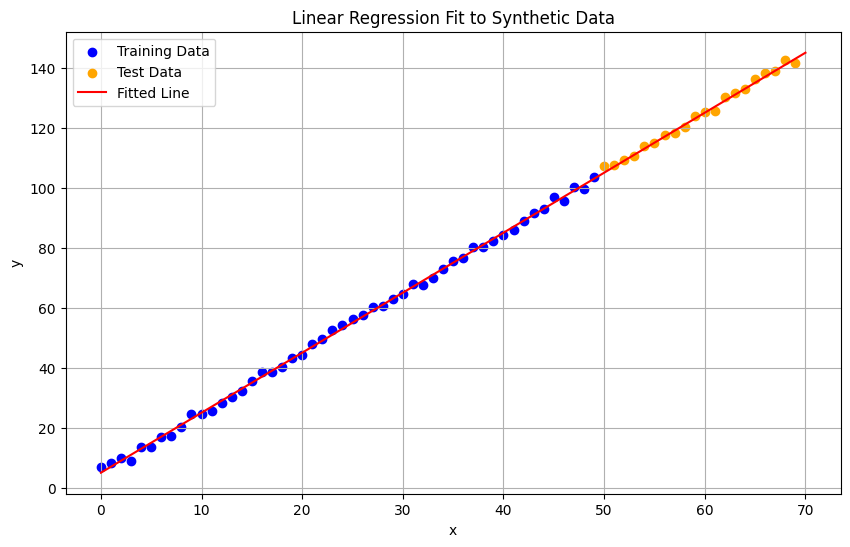

In [8]:
# plot the training and test data and the fitted line from the estimated parameters
plt.figure(figsize=(10, 6))
plt.scatter(x_train.numpy(), y_train.numpy(), color='blue', label='Training Data')
plt.scatter(x_test.numpy(), y_test.numpy(), color='orange', label='Test Data')
x_line = torch.linspace(0, batch_size + 20, 100).reshape(-1, 1)
y_line = b_est + w_est * x_line
plt.plot(x_line.numpy(), y_line.numpy(), color='red', label='Fitted Line')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Linear Regression Fit to Synthetic Data')
plt.legend()
plt.grid()
plt.show()  

__Linear regression by torch.nn.Linear__

nn.Linear(input_dim, output_dim) defines a function 
$$f(x, w, b) = x w^T+b$$
where 

- $x \in \mathbb R^{1\times n}$ is the input, where $n$ is equal to input_dim

- $w \in \mathbb R^{m\times n}$ is randomly assigned weight, where $m$ is equal to output_dim

- $b \in \mathbb R^{1\times m}$ is randomly assigned bias.

In [9]:
# A simple illustration of nn.Linear layer and its parameters
input_dim = 2 
output_dim = 1
model = nn.Linear(input_dim, output_dim)
print(f"Initial weight:\n{model.weight.data}")
print(f"Initial bias:\n{model.bias.data}")

Initial weight:
tensor([[-0.2420, -0.5581]])
Initial bias:
tensor([0.5929])


In [10]:
# Alternatively, one can also access the parameters as follows
for p in model.parameters():
    print(p.data)

tensor([[-0.2420, -0.5581]])
tensor([0.5929])


In [11]:
# One can change parameters by directly assigning new values to them. 
# For example, let's set the weight to [[2.0, 3.0]] and bias to [1.0]
with torch.no_grad():
    model.weight.copy_(torch.tensor([[2.0, 3.0]], dtype=model.weight.dtype, device=model.weight.device))
    model.bias.copy_(torch.tensor([1.0], dtype=model.bias.dtype, device=model.bias.device))

print("Updated weight:\n", model.weight.data)
print("Updated bias:\n", model.bias.data)


Updated weight:
 tensor([[2., 3.]])
Updated bias:
 tensor([1.])


In [12]:
# Test the computation of the linear model
# Define an input tensor
x_test_compute = torch.tensor([[4.0, 5.0]])

# Forward pass using the model
y_model = model(x_test_compute)
print(f"Model output: {y_model.item()}")

# Manual computation: y = x @ W.T + b
# Weights are [[2.0, 3.0]], bias is [1.0]
# Computation: (4.0 * 2.0) + (5.0 * 3.0) + 1.0 = 8 + 15 + 1 = 24
y_manual = x_test_compute @ model.weight.T + model.bias
print(f"Manual computation: {y_manual.item()}")

# Verify
assert torch.abs(y_model - y_manual) < 1e-6, "Computation mismatch!"
print("Verification successful.")

Model output: 24.0
Manual computation: 24.0
Verification successful.


## Linear regression by nn.Linear

Next, we are going to use nn.Linear function to solve linear regression

In [13]:
# set up model
model = nn.Linear(1, 1)  # input dimension 1, output dimension 1
print(f"Initial paremeters (bias and weight):\n{model.bias.data}, {model.weight.data}")
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.01) # Adam is better than SGD for this simple example, but feel free to try SGD as well 

epoch_n = 10000
print_every = 10
epoch_per_print = epoch_n // print_every

for epoch in range(epoch_n):
    optimizer.zero_grad()
    y_pred = model(x_train)
    loss = criterion(y_pred, y_train)
    loss.backward()
    optimizer.step()

    if (epoch + 1) % epoch_per_print == 0:
        print(f"Epoch [{epoch+1}/{epoch_n}], y_pred: {y_pred[0].item():.4f} Loss: {loss.item():.4f}")

# print the final parameters after training
print(f"Final parameters (bias and weight) by optimizer:\n{model.bias.data}, {model.weight.data}")


Initial paremeters (bias and weight):
tensor([0.8604]), tensor([[-0.1985]])
Epoch [1000/10000], y_pred: 3.3036 Loss: 1.9257
Epoch [2000/10000], y_pred: 3.7169 Loss: 1.5833
Epoch [3000/10000], y_pred: 4.2371 Loss: 1.2776
Epoch [4000/10000], y_pred: 4.7173 Loss: 1.1191
Epoch [5000/10000], y_pred: 5.0105 Loss: 1.0808
Epoch [6000/10000], y_pred: 5.1057 Loss: 1.0779
Epoch [7000/10000], y_pred: 5.1173 Loss: 1.0779
Epoch [8000/10000], y_pred: 5.1175 Loss: 1.0779
Epoch [9000/10000], y_pred: 5.1175 Loss: 1.0779
Epoch [10000/10000], y_pred: 5.1176 Loss: 1.0779
Final parameters (bias and weight) by optimizer:
tensor([5.1176]), tensor([[1.9991]])


## Conclusion

- We implemented linear regression using two approaches: a **linear algebra** closed-form solution and an **optimization-based** solution.
- We used `torch.linalg.solve` to estimate parameters from the normal equation.
- We evaluated model quality with mean squared error (MSE), including both a manual implementation and PyTorch’s `nn.MSELoss`.
- We also used `nn.Linear`, which is a core building block for neural network models in PyTorch.
- Both methods produced a good fit to the synthetic data and recovered parameters close to the ground truth.
